<a href="https://colab.research.google.com/github/ayatayoub20/Time-Series-Analysis/blob/main/ARIMA_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.0 MB/s eta 0:00:00


In [10]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.tsa.api as tsa
from pmdarima.model_selection import train_test_split
from pmdarima.arima.utils import ndiffs

# Set wide fig size for plots
plt.rcParams['figure.figsize']=(12,3)

#Custom Functions


In [11]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)

    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)

    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")

    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                   forecast_df['mean_ci_upper'],
                   color='green', alpha=0.3,  lw=2)

    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [12]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [42]:
def regression_metrics_ts(ts_true, ts_pred, label=""):

    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = np.sqrt(mse)
    r_squared = r2_score(ts_true, ts_pred)
    mape = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    print("-"*50)
    print(label)
    print("-"*50)
    print(f"MAE  : {mae:.3f}")
    print(f"MSE  : {mse:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R²   : {r_squared:.3f}")
    print(f"MAPE : {mape:.2f}%")

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r_squared,
        "MAPE": mape
    }

In [14]:
def get_sig_lags(ts, type='ACF',  nlags=None,alpha=0.5):


    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type=='PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags =range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type:corr_values,
                            'Lags':lags,
                            'lower ci': conf_int[:,0]-corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1]-corr_values, # subtact acf to upper ci to center
                                 })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags= corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags!=0]

    return sig_lags

In [15]:
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)


    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')

    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )

    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)




    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")

        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m

        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")

    fig.tight_layout()

    return fig

In [16]:
url = "https://drive.google.com/uc?id=1KKR8TZbkixVN2NundM2mEVv5AhjHhs9a"

df = pd.read_csv(url)
df.head()

,Date,Adj Close
0,2000-01-03,44.915394
1,2000-01-04,43.234756
2,2000-01-05,42.352402
3,2000-01-06,42.814564
4,2000-01-07,46.049828


In [17]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Set Date as index
df = df.set_index("Date")

df.head()

,Adj Close
Date,
2000-01-03,44.915394
2000-01-04,43.234756
2000-01-05,42.352402
2000-01-06,42.814564
2000-01-07,46.049828


In [18]:
# Select only 2010-2020
ts = df.loc["2010":"2020", "Adj Close"]

ts.head()

,Adj Close
Date,
2010-01-01,NaN
2010-01-04,40.963638
2010-01-05,40.555729
2010-01-06,40.465084
2010-01-07,40.487759


In [19]:
# Convert to business day frequency
ts = ts.resample("B").asfreq()

ts.head(10)

,Adj Close
Date,
2010-01-01,NaN
2010-01-04,40.963638
2010-01-05,40.555729
2010-01-06,40.465084
2010-01-07,40.487759
2010-01-08,40.283802
2010-01-11,40.948536
2010-01-12,41.341316
2010-01-13,41.552811


In [20]:
ts.isna().sum()

np.int64(101)

In [21]:
# Fill missing values using previous day's value
ts = ts.ffill()

In [22]:
ts.isna().sum()

np.int64(1)

In [23]:
ts = ts.dropna()

In [24]:
ts.isna().sum()

np.int64(0)

#Plot the Time Series

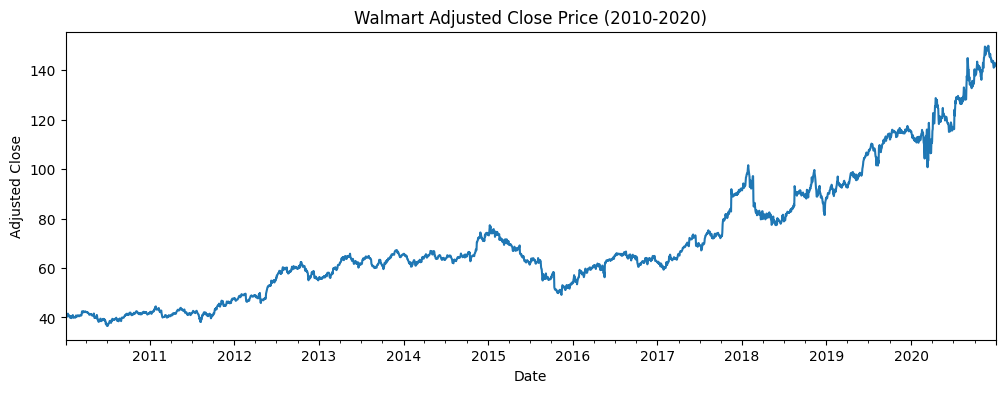

In [25]:
plt.figure(figsize=(12,4))

ts.plot()

plt.title("Walmart Adjusted Close Price (2010-2020)")
plt.ylabel("Adjusted Close")

plt.show()

##ADF Test

In [26]:
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs):

    test_stat, pval, nlags, nobs, crit_vals_d, icbest = tsa.adfuller(ts, **kwargs)

    results = {
        "Test Statistic": test_stat,
        "# of Lags Used": nlags,
        "# of Observations": nobs,
        "p-value": round(pval,6),
        "alpha": alpha,
        "sig/stationary?": pval < alpha
    }

    return pd.DataFrame(results,index=[label])

In [27]:
get_adfuller_results(ts,label="Raw Data")

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
Raw Data,1.436262,23,2845,0.997273,0.05,False


In [28]:
d = ndiffs(ts)

print(f"d = {d}")

d = 1


Differencing

In [29]:
ts_diff = ts.diff().dropna()

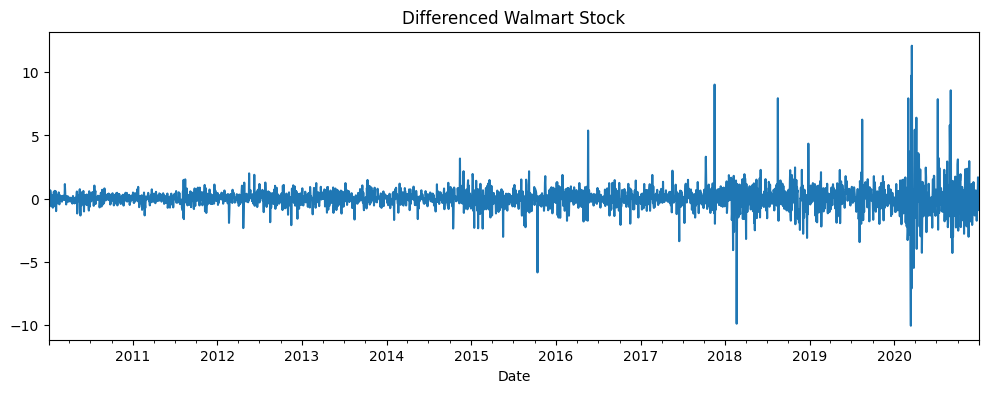

In [30]:
plt.figure(figsize=(12,4))

ts_diff.plot()

plt.title("Differenced Walmart Stock")

plt.show()

In [31]:
get_adfuller_results(ts_diff,label="Differenced Data")

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
Differenced Data,-12.215558,22,2845,0.0,0.05,True


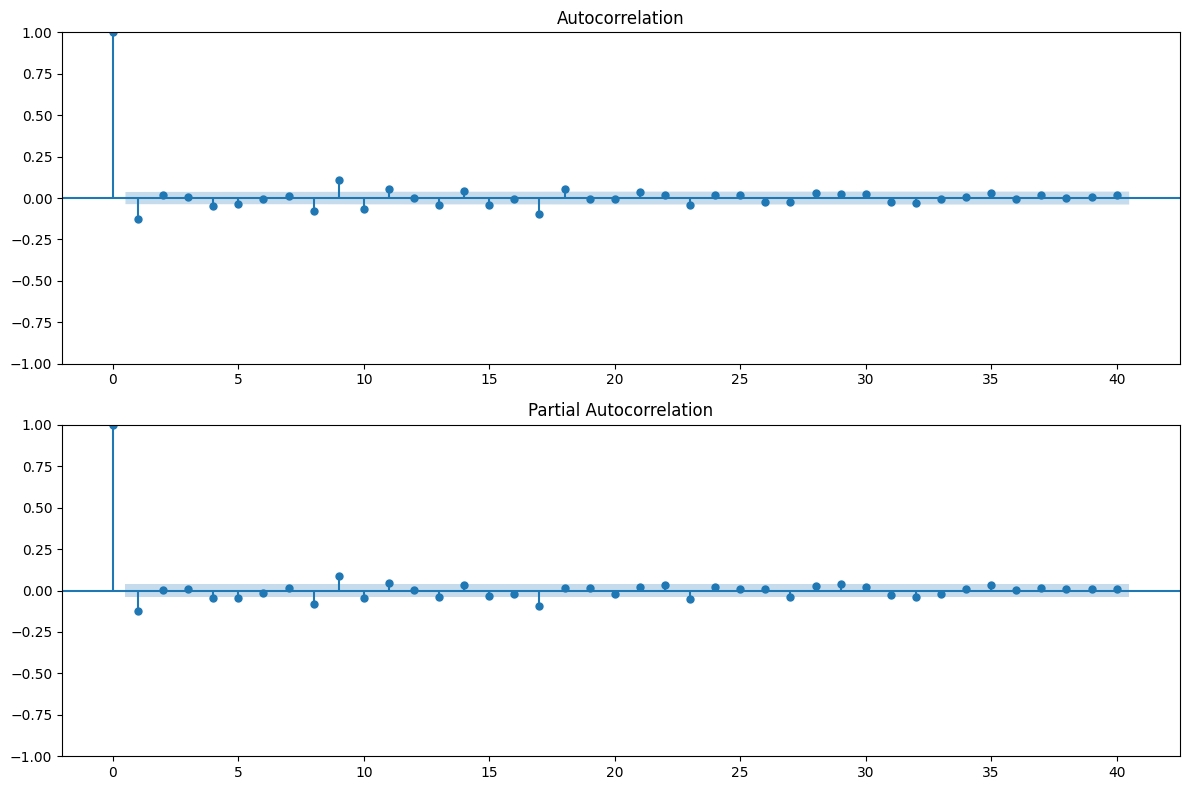

In [32]:
fig, axes = plt.subplots(2,1,figsize=(12,8))

tsa.graphics.plot_acf(ts_diff,
                      lags=40,
                      ax=axes[0])

tsa.graphics.plot_pacf(ts_diff,
                       lags=40,
                       ax=axes[1])

plt.tight_layout()

plt.show()

Train/Test Split

In [33]:
n_test_lags = 13 * 5
n_test_lags

65

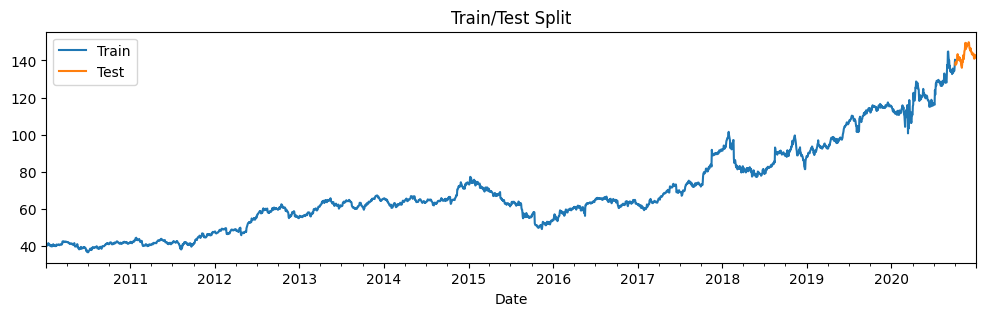

In [34]:
train, test = train_test_split(ts, test_size=n_test_lags)

ax = train.plot(label="Train")
test.plot(ax=ax, label="Test")
plt.title("Train/Test Split")
plt.legend()
plt.show()

In [35]:
p = 1
d = 1
q = 1

initial_model = tsa.ARIMA(train, order=(p, d, q)).fit()
initial_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              Adj Close   No. Observations:                 2804
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3887.572
Date:                Wed, 08 Jul 2026   AIC                           7781.144
Time:                        09:12:05   BIC                           7798.959
Sample:                    01-04-2010   HQIC                          7787.574
                         - 10-01-2020                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1806      0.050     -3.633      0.000      -0.278      -0.083
ma.L1          0.0621      0.052      1.190      0.234      -0.040       0.164
sigma2         0.9380      0.006    146.420      0.000       0.925       0.951
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):            113802.75
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):              10.47   Skew:                             0.95
Prob(H) (two-sided):                  0.00   Kurtosis:                        34.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [46]:
p_values = range(0,6)
d_values = [1]
q_values = range(0,6)

pdq = list(itertools.product(p_values,d_values,q_values))

In [47]:
best_aic = float("inf")
best_pdq = None

results = []

for order in pdq:

    try:

        model = tsa.ARIMA(train,order=order).fit()

        results.append({
            "Order":order,
            "AIC":model.aic
        })

        if model.aic < best_aic:

            best_aic = model.aic
            best_pdq = order

    except:
        continue

results_df = pd.DataFrame(results).sort_values("AIC")

results_df.head(10)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/st

,Order,AIC
29,"(4, 1, 5)",7749.434830
35,"(5, 1, 5)",7755.440144
34,"(5, 1, 4)",7756.201550
28,"(4, 1, 4)",7758.029352
23,"(3, 1, 5)",7758.830488
27,"(4, 1, 3)",7765.864201
33,"(5, 1, 3)",7768.089096
22,"(3, 1, 4)",7768.274290
15,"(2, 1, 3)",7769.195756
26,"(4, 1, 2)",7771.138193


In [48]:
best_order = (4, 1, 5)

best_model = tsa.ARIMA(train, order=best_order).fit()

best_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              Adj Close   No. Observations:                 2804
Model:                 ARIMA(4, 1, 5)   Log Likelihood               -3864.717
Date:                Wed, 08 Jul 2026   AIC                           7749.435
Time:                        10:32:18   BIC                           7808.819
Sample:                    01-04-2010   HQIC                          7770.869
                         - 10-01-2020                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2770      0.060     -4.616      0.000      -0.395      -0.159
ar.L2          1.0388      0.055     18.815      0.000       0.931       1.147
ar.L3         -0.1944      0.057     -3.402      0.001      -0.306      -0.082
ar.L4         -0.7621      0.046    -16.667      0.000      -0.852      -0.672
ma.L1          0.1620      0.060      2.690      0.007       0.044       0.280
ma.L2         -1.0533      0.055    -19.052      0.000      -1.162      -0.945
ma.L3          0.3168      0.059      5.329      0.000       0.200       0.433
ma.L4          0.6705      0.048     14.023      0.000       0.577       0.764
ma.L5         -0.0974      0.011     -8.740      0.000      -0.119      -0.076
sigma2         0.9228      0.008    123.014      0.000       0.908       0.937
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             92249.38
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):              10.10   Skew:                             0.89
Prob(H) (two-sided):                  0.00   Kurtosis:                        31.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

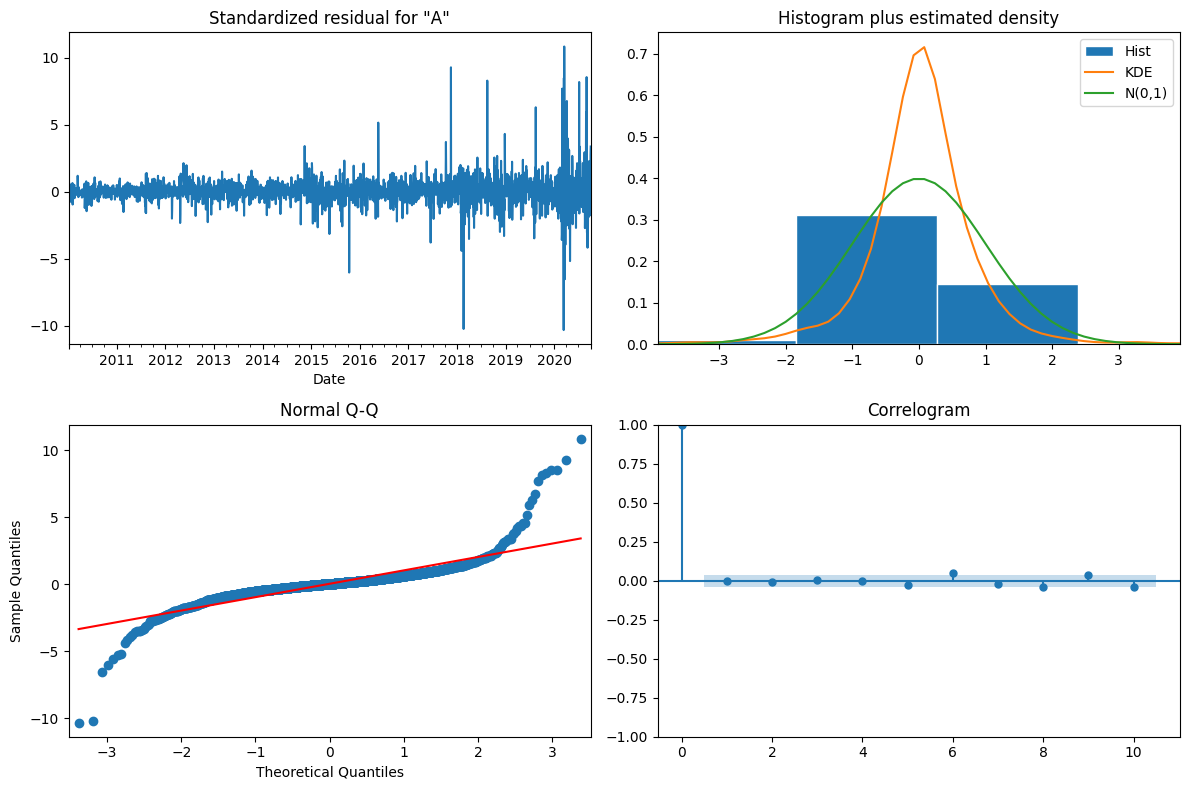

In [49]:
fig = best_model.plot_diagnostics()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

In [50]:
best_forecast_df = best_model.get_forecast(steps=len(test)).summary_frame()
best_forecast_df.head()

Adj Close,mean,mean_se,mean_ci_lower,mean_ci_upper
2020-10-02,139.787589,0.960599,137.904848,141.670329
2020-10-05,139.993575,1.282766,137.479400,142.507749
2020-10-06,139.546540,1.548131,136.512259,142.580822
2020-10-07,139.537169,1.773390,136.061388,143.012950
2020-10-08,139.130541,1.952225,135.304251,142.956831


--------------------------------------------------
Final ARIMA(4,1,5)
--------------------------------------------------
MAE  : 4.175
MSE  : 26.520
RMSE : 5.150
R²   : -1.062
MAPE : 2.87%


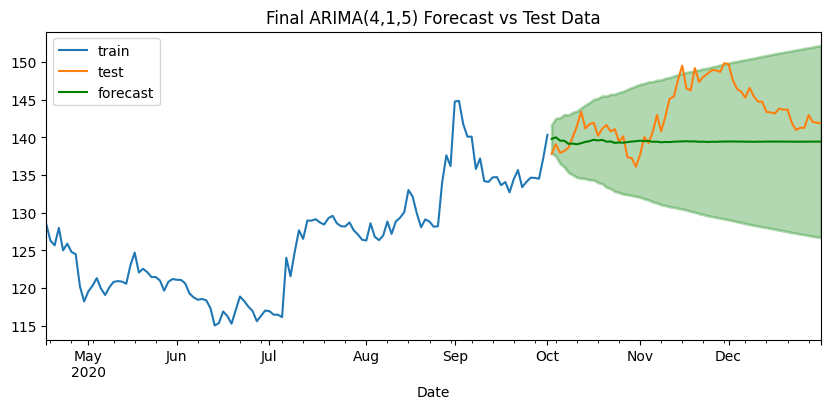

In [51]:
best_forecast_df = best_model.get_forecast(steps=len(test)).summary_frame()

plot_forecast(
    train,
    test,
    best_forecast_df,
    n_train_lags=120,
    title="Final ARIMA(4,1,5) Forecast vs Test Data"
)

best_metrics = regression_metrics_ts(
    test,
    best_forecast_df["mean"],
    label="Final ARIMA(4,1,5)"
)

##Final Model Selection

The final selected model was ARIMA(4,1,5). This model was chosen because it achieved the lowest AIC value (7749.43) among all the ARIMA models tested during the model comparison process. Additionally, all AR and MA coefficients were statistically significant (p-value < 0.05), indicating that each parameter contributed meaningfully to the model.

##Model Performance

The model achieved a Mean Absolute Percentage Error (MAPE) of 2.87% on the test dataset. This means that, on average, the forecasted values differed from the actual Walmart adjusted closing prices by approximately 2.87%. Overall, this indicates good forecasting performance for the selected time period.

##Visual Evaluation

From the forecast plot, the model successfully captured the overall trend of the Walmart stock prices during the test period. Although it did not capture every short-term fluctuation in the stock price, the predicted values generally followed the direction of the actual observations. As expected, the confidence interval became wider over time, indicating increased uncertainty in longer-term forecasts.

Overall, the ARIMA(4,1,5) model provided a reasonable balance between statistical fit and forecasting performance, making it the final model selected for this assignment.
